# COMSOL field visualization

Centered on the central hole. The COMSOL domain is a rectangle:
- Central hole at corner (x_max, z_min) = (3.37, 6.20) → shifted to origin (0, 0)
- Neighbor hole at 150° at corner (x_min, z_max) = (-5.33, 11.20)
- y = drift direction (hole axis)
- Sector covered: 150° to 180° (30° unique sector)

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

data = np.loadtxt("../data/Mesh-MTHGEM_fields_4bar.txt", skiprows=9)
xr, yr, zr, V = data[:,0], data[:,1], data[:,2], data[:,3]

# Shift: central hole at (x_max, z_min) -> origin
x0, z0 = xr.max(), zr.min()
x = xr - x0   # x' in [-8.70, 0]
z = zr - z0   # z' in [0, 5.00]
y = yr         # drift, unchanged

# Neighbor hole at 150°
xB, zB = x.min(), z.max()
dist = np.sqrt(xB**2 + zB**2)
angle = np.degrees(np.arctan2(zB, xB))

print(f"Central hole at origin (0, 0)")
print(f"Neighbor hole at ({xB:.2f}, {zB:.2f}), dist = {dist:.2f} mm, angle = {angle:.1f}°")
print(f"Domain: x'=[{x.min():.2f}, {x.max():.2f}], z'=[{z.min():.2f}, {z.max():.2f}]")
print(f"y: [{y.min():.2f}, {y.max():.2f}] mm")
print(f"V: [{V.min():.0f}, {V.max():.0f}] V")

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.
Central hole at origin (0, 0)
Neighbor hole at (-8.70, 5.00), dist = 10.03 mm, angle = 150.1°
Domain: x'=[-8.70, 0.00], z'=[0.00, 5.00]
y: [-0.85, 102.99] mm
V: [-2500, 0] V


In [17]:
def interp_slab(coord1, coord2, val, c1_grid, c2_grid):
    """2D griddata interpolation from scattered slab data."""
    pts = np.column_stack([coord1, coord2])
    C1, C2 = np.meshgrid(c1_grid, c2_grid)
    query = np.column_stack([C1.ravel(), C2.ravel()])
    Vi = griddata(pts, val, query, method='linear')
    nans = np.isnan(Vi)
    if nans.any():
        Vi[nans] = griddata(pts, val, query[nans], method='nearest')
    return C1, C2, Vi.reshape(C1.shape)

def add_E_arrows(ax, c1_grid, c2_grid, Vmap, skip=3, color='white', scale=50):
    """Overlay E-field arrows on a V map. E = -grad(V)."""
    dc1 = c1_grid[1] - c1_grid[0]
    dc2 = c2_grid[1] - c2_grid[0]
    E1 = -np.gradient(Vmap, dc1, axis=1)
    E2 = -np.gradient(Vmap, dc2, axis=0)
    Emag = np.sqrt(E1**2 + E2**2)
    Enorm = np.maximum(Emag, 1e-6)
    C1, C2 = np.meshgrid(c1_grid, c2_grid)
    s = skip
    ax.quiver(C1[::s, ::s], C2[::s, ::s],
              E1[::s, ::s]/Enorm[::s, ::s], E2[::s, ::s]/Enorm[::s, ::s],
              color=color, alpha=0.7, scale=scale, width=0.003,
              headwidth=4, headlength=5)

print("Helper functions ready.")

Helper functions ready.


## 1. Horizontal sections: V(x', z') at fixed y

Slices in the transverse plane. Central hole at origin, neighbor at 150°.

y=-0.2: 324434 nodes  y=+0.5: 20216 nodes  y=+1.5: 4416 nodes  y=+2.5: 35010 nodes  y=+3.5: 25810 nodes  y=+5.0: 1344 nodes  


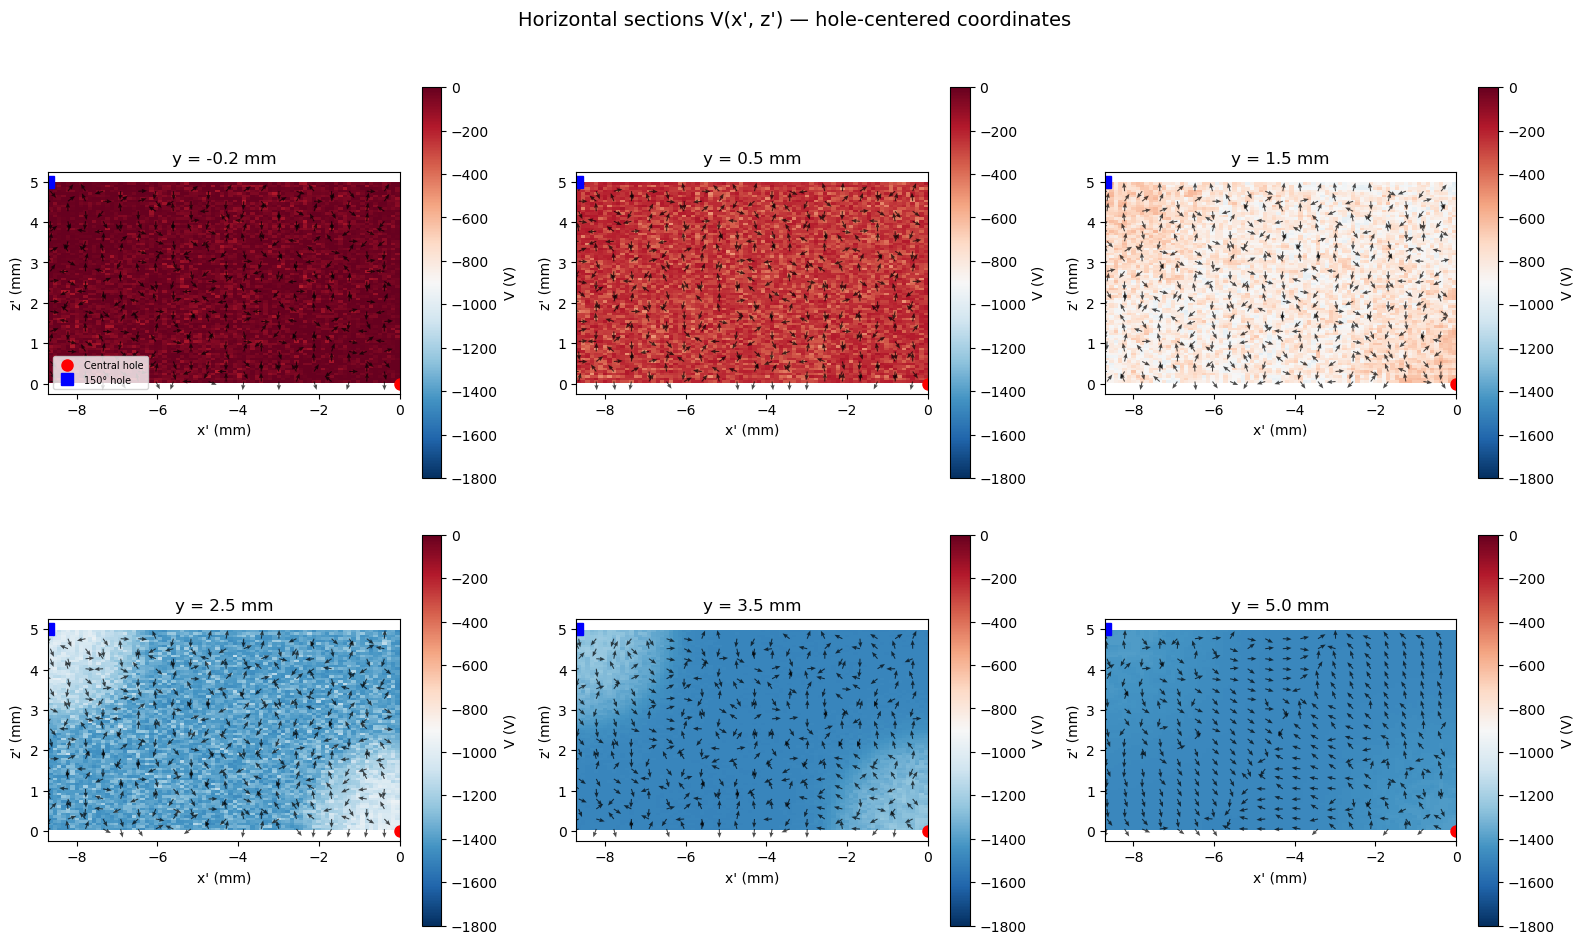

In [18]:
y_cuts = [-0.2, 0.5, 1.5, 2.5, 3.5, 5.0]
y_tol  = 0.4

xg = np.linspace(x.min() + 0.05, x.max() - 0.05, 80)
zg = np.linspace(z.min() + 0.05, z.max() - 0.05, 80)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for i, yc in enumerate(y_cuts):
    ax = axes.flat[i]
    mask = np.abs(y - yc) < y_tol
    print(f"y={yc:+.1f}: {mask.sum()} nodes", end="  ", flush=True)
    
    _, _, Vi = interp_slab(x[mask], z[mask], V[mask], xg, zg)
    
    im = ax.pcolormesh(xg, zg, Vi, cmap='RdBu_r', shading='auto', vmin=-1800, vmax=0)
    add_E_arrows(ax, xg, zg, Vi, skip=4, color='k', scale=40)
    
    # Mark holes
    ax.plot(0, 0, 'ro', ms=8, label='Central hole')
    ax.plot(xB, zB, 'bs', ms=8, label='150° hole')
    
    ax.set_title(f"y = {yc:.1f} mm")
    ax.set_xlabel("x' (mm)")
    ax.set_ylabel("z' (mm)")
    ax.set_aspect('equal')
    fig.colorbar(im, ax=ax, shrink=0.8, label="V (V)")

print()
axes.flat[0].legend(fontsize=7, loc='lower left')
fig.suptitle("Horizontal sections V(x', z') — hole-centered coordinates", fontsize=14)
plt.tight_layout()
plt.show()

## 2. Lateral section: V(x', y) at fixed z'

Vertical cuts parallel to the x'-axis at 6 z' values.

z'=0.2: 78028 nodes  z'=1.1: 84100 nodes  z'=2.0: 79421 nodes  z'=3.0: 79654 nodes  z'=3.9: 84089 nodes  z'=4.8: 77383 nodes  


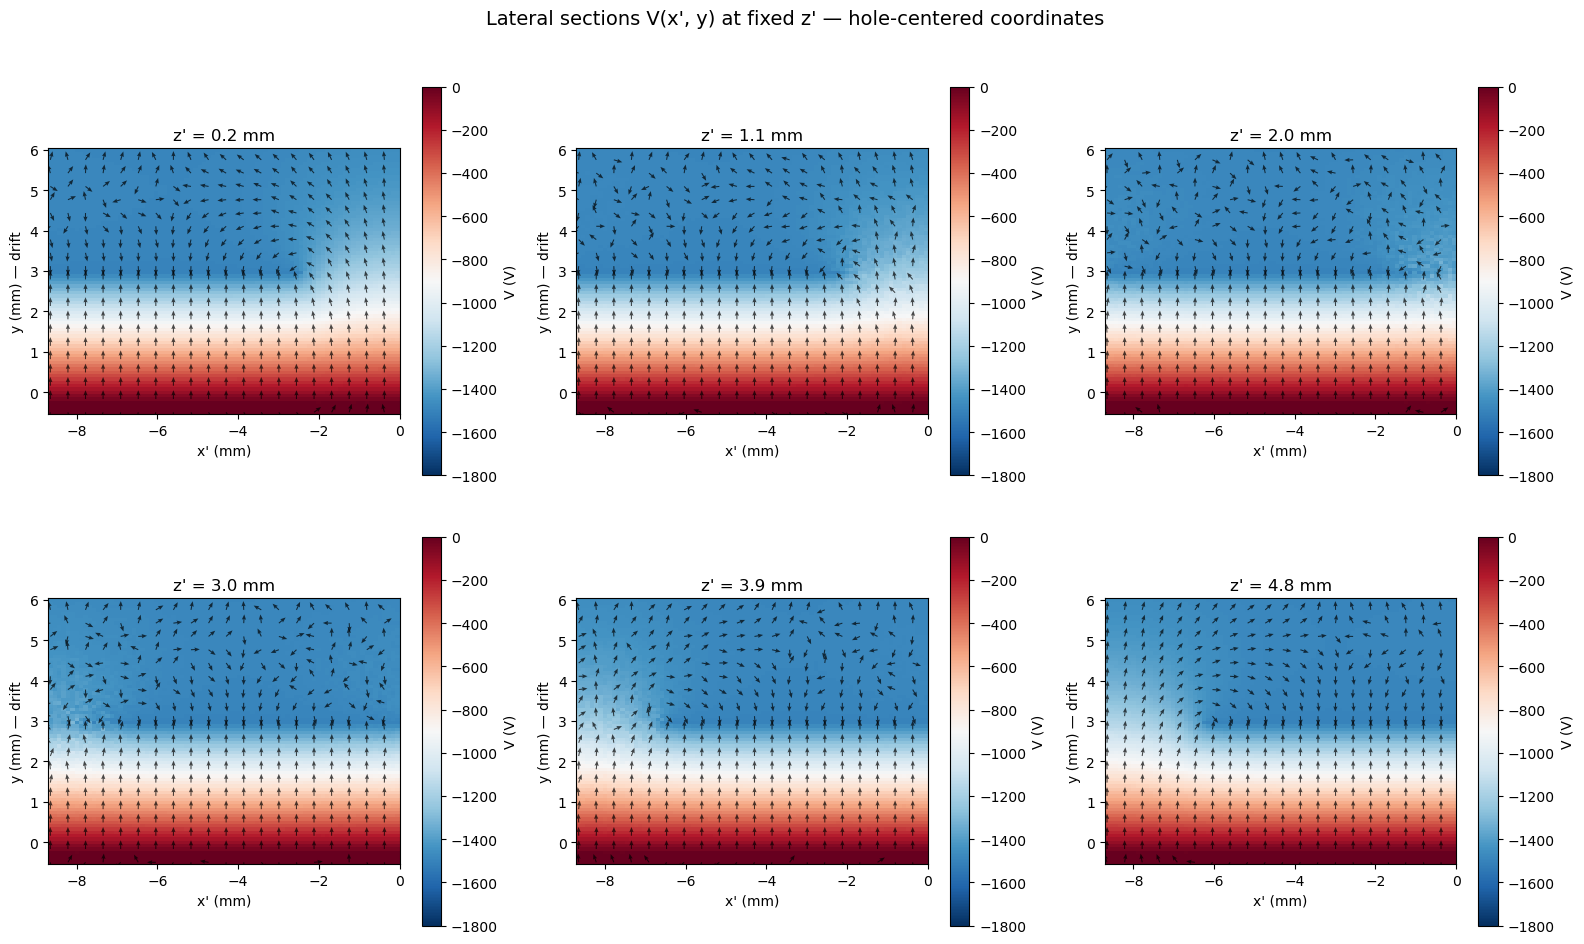

In [19]:
z_cuts = np.linspace(z.min() + 0.2, z.max() - 0.2, 6)
z_tol  = 0.4

xg2 = np.linspace(x.min() + 0.05, x.max() - 0.05, 80)
yg2 = np.linspace(-0.5, 6.0, 80)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for i, zc in enumerate(z_cuts):
    ax = axes.flat[i]
    mask = np.abs(z - zc) < z_tol
    print(f"z'={zc:.1f}: {mask.sum()} nodes", end="  ", flush=True)
    
    _, _, Vi = interp_slab(x[mask], y[mask], V[mask], xg2, yg2)
    
    im = ax.pcolormesh(xg2, yg2, Vi, cmap='RdBu_r', shading='auto', vmin=-1800, vmax=0)
    add_E_arrows(ax, xg2, yg2, Vi, skip=4, color='k', scale=40)
    
    ax.set_title(f"z' = {zc:.1f} mm")
    ax.set_xlabel("x' (mm)")
    ax.set_ylabel("y (mm) — drift")
    ax.set_aspect('equal')
    fig.colorbar(im, ax=ax, shrink=0.8, label="V (V)")

print()
fig.suptitle("Lateral sections V(x', y) at fixed z' — hole-centered coordinates", fontsize=14)
plt.tight_layout()
plt.show()

## 3. Lateral section: V(z', y) at fixed x'

Vertical cuts parallel to the z'-axis at 6 x' values.

x'=-8.5: 61515 nodes  x'=-6.8: 62726 nodes  x'=-5.2: 27799 nodes  x'=-3.5: 27999 nodes  x'=-1.9: 63272 nodes  x'=-0.2: 61685 nodes  


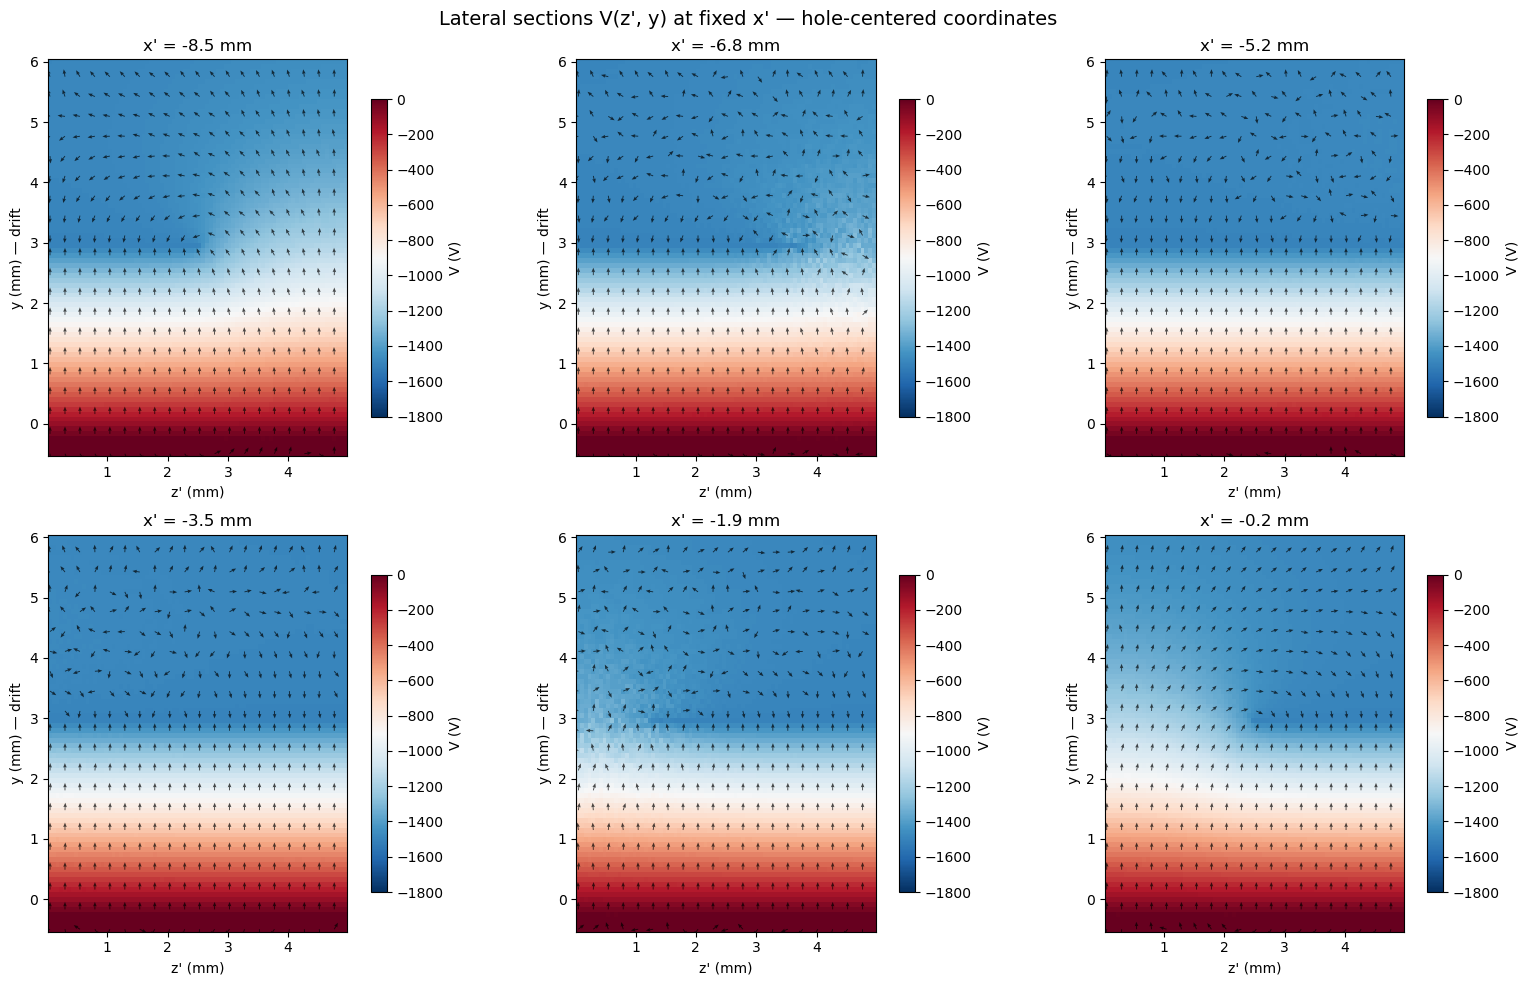

In [20]:
x_cuts = np.linspace(x.min() + 0.2, x.max() - 0.2, 6)
x_tol  = 0.4

zg3 = np.linspace(z.min() + 0.05, z.max() - 0.05, 80)
yg3 = np.linspace(-0.5, 6.0, 80)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for i, xc in enumerate(x_cuts):
    ax = axes.flat[i]
    mask = np.abs(x - xc) < x_tol
    print(f"x'={xc:.1f}: {mask.sum()} nodes", end="  ", flush=True)
    
    _, _, Vi = interp_slab(z[mask], y[mask], V[mask], zg3, yg3)
    
    im = ax.pcolormesh(zg3, yg3, Vi, cmap='RdBu_r', shading='auto', vmin=-1800, vmax=0)
    add_E_arrows(ax, zg3, yg3, Vi, skip=4, color='k', scale=40)
    
    ax.set_title(f"x' = {xc:.1f} mm")
    ax.set_xlabel("z' (mm)")
    ax.set_ylabel("y (mm) — drift")
    ax.set_aspect('equal')
    fig.colorbar(im, ax=ax, shrink=0.8, label="V (V)")

print()
fig.suptitle("Lateral sections V(z', y) at fixed x' — hole-centered coordinates", fontsize=14)
plt.tight_layout()
plt.show()

## 4. V(y) and Ey(y) profiles at corners and center

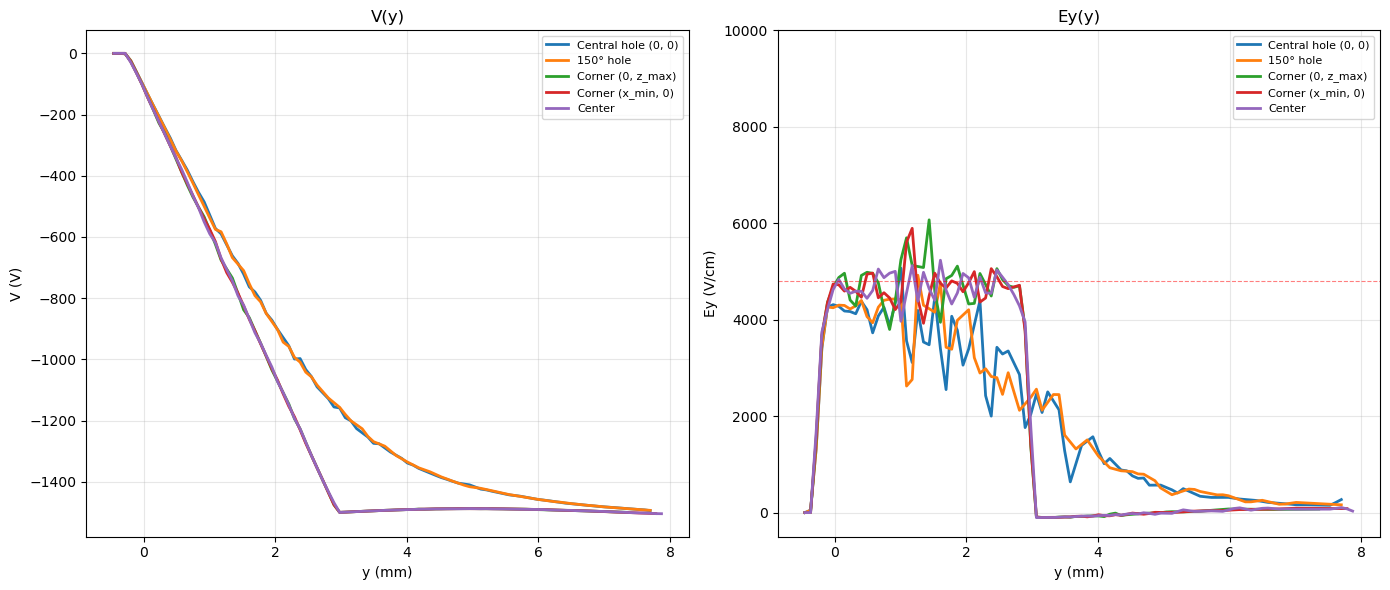

In [21]:
corners = {
    'Central hole (0, 0)':   (0, 0),
    '150° hole':             (xB, zB),
    'Corner (0, z_max)':     (0, z.max()),
    'Corner (x_min, 0)':     (x.min(), 0),
    'Center':                (x.mean(), z.mean()),
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

for name, (xc, zc) in corners.items():
    r = np.sqrt((x - xc)**2 + (z - zc)**2)
    mask = r < 0.5
    if mask.sum() < 10:
        continue
    ys, Vs = y[mask], V[mask]
    idx = np.argsort(ys)
    ys, Vs = ys[idx], Vs[idx]
    
    # Smooth with binning
    ybins = np.linspace(-0.5, 8.0, 100)
    yc_bin = (ybins[:-1] + ybins[1:]) / 2
    V_bin = np.array([Vs[(ys >= ybins[j]) & (ys < ybins[j+1])].mean()
                      if ((ys >= ybins[j]) & (ys < ybins[j+1])).sum() > 0 else np.nan
                      for j in range(len(ybins)-1)])
    valid = ~np.isnan(V_bin)
    ax1.plot(yc_bin[valid], V_bin[valid], '-', lw=2, label=name)
    
    if valid.sum() > 5:
        Ey = -np.gradient(V_bin[valid], yc_bin[valid]) * 10
        ax2.plot(yc_bin[valid], Ey, '-', lw=2, label=name)

ax1.set_xlabel("y (mm)"); ax1.set_ylabel("V (V)")
ax1.set_title("V(y)"); ax1.legend(fontsize=8); ax1.grid(True, alpha=0.3)

ax2.set_xlabel("y (mm)"); ax2.set_ylabel("Ey (V/cm)")
ax2.set_title("Ey(y)"); ax2.legend(fontsize=8); ax2.grid(True, alpha=0.3)
ax2.set_ylim(-500, 10000)
ax2.axhline(y=4800, color='red', ls='--', lw=0.8, alpha=0.5)

plt.tight_layout()
plt.show()

## 5. Radial sections: V(r, y) at azimuthal angles from 180° to 150°

Vertical slices through the central hole axis at 6 angles spanning the unique sector. r is the radial distance from the hole axis in the (x', z') plane, positive outward.

phi=180°: 56506 nodes  phi=174°: 79046 nodes  phi=168°: 87412 nodes  phi=162°: 105569 nodes  phi=156°: 118545 nodes  phi=150°: 124816 nodes  


/var/folders/56/_pmdccc97ljb_l3v3s6gkrxm0000gn/T/ipykernel_7235/1038193957.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


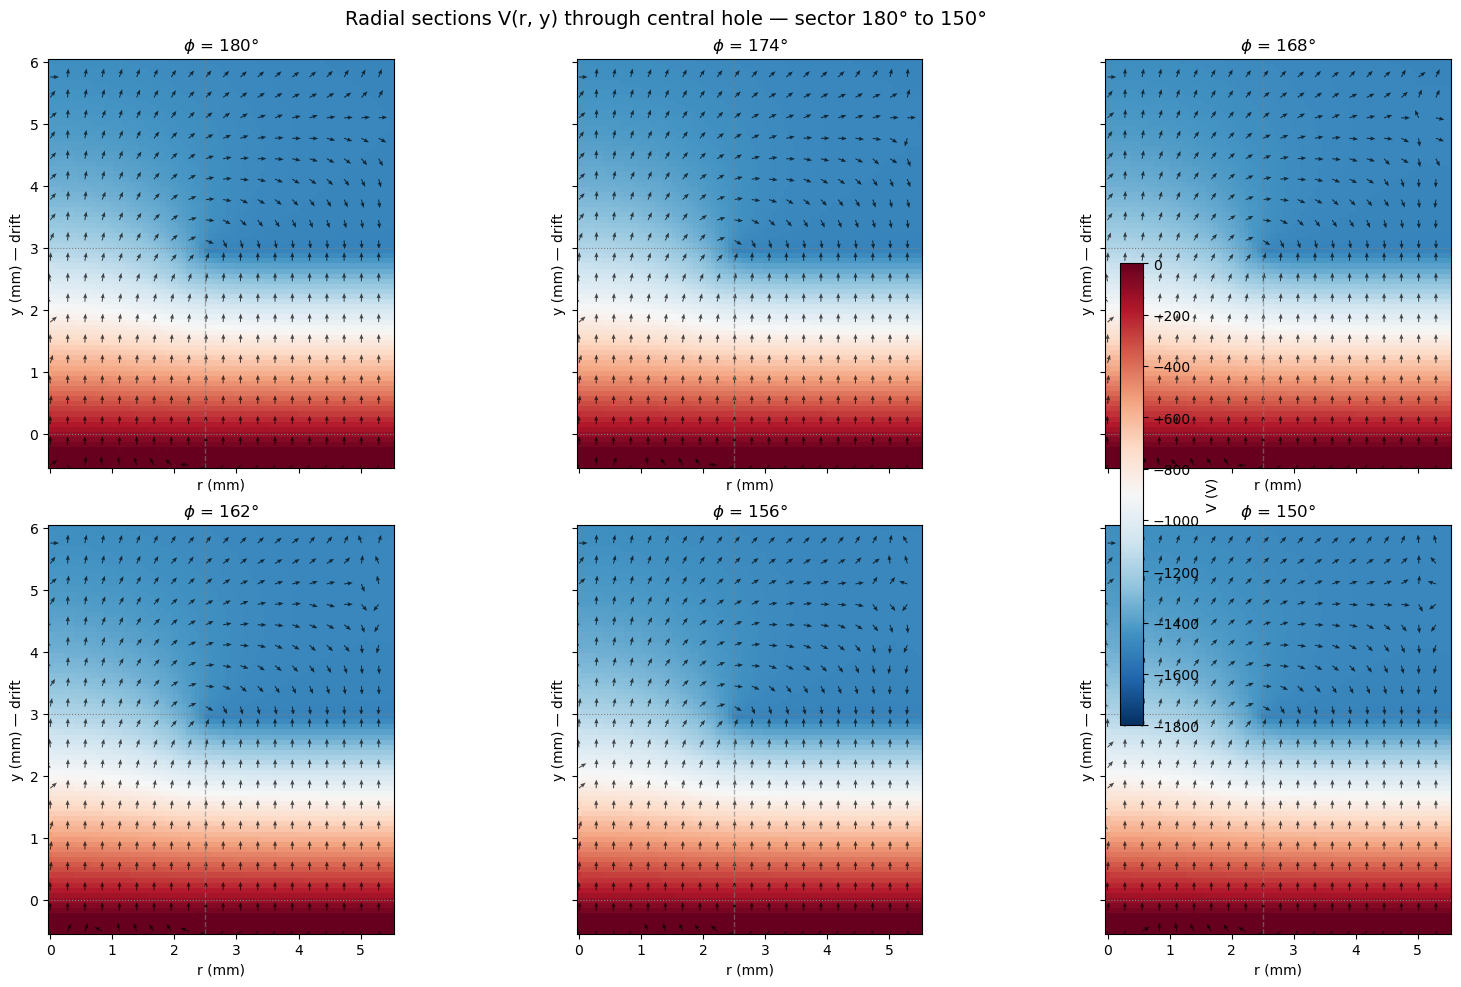

In [22]:
phi_angles = [180, 174, 168, 162, 156, 150]  # degrees

rg = np.linspace(0, 5.5, 80)   # radial distance from hole axis
yg_r = np.linspace(-0.5, 6.0, 80)
r_tol = 0.4  # slab half-width perpendicular to slice

fig, axes = plt.subplots(2, 3, figsize=(16, 10), sharex=True, sharey=True)

for i, phi in enumerate(phi_angles):
    ax = axes.flat[i]
    phi_rad = np.radians(phi)
    
    # Direction unit vector for this angle
    dx = np.cos(phi_rad)
    dz = np.sin(phi_rad)
    
    # For each data point, compute:
    #   r_along = projection onto the slice direction (signed distance along ray)
    #   r_perp  = perpendicular distance to the slice plane
    r_along = x * dx + z * dz
    r_perp  = np.abs(-x * dz + z * dx)
    
    # Select nodes near this slice
    mask = r_perp < r_tol
    print(f"phi={phi}°: {mask.sum()} nodes", end="  ", flush=True)
    
    if mask.sum() < 100:
        print("(too few, skipping)")
        continue
    
    _, _, Vi = interp_slab(r_along[mask], y[mask], V[mask], rg, yg_r)
    
    im = ax.pcolormesh(rg, yg_r, Vi, cmap='RdBu_r', shading='auto', vmin=-1800, vmax=0)
    add_E_arrows(ax, rg, yg_r, Vi, skip=4, color='k', scale=40)
    
    # Hole radius
    ax.axvline(x=2.5, color='gray', ls='--', lw=1, alpha=0.6)
    ax.axhline(y=0, color='gray', ls=':', lw=0.8)
    ax.axhline(y=3, color='gray', ls=':', lw=0.8)
    
    ax.set_title(f"$\\phi$ = {phi}°")
    ax.set_xlabel("r (mm)")
    ax.set_ylabel("y (mm) — drift")
    ax.set_aspect('equal')

print()
fig.colorbar(im, ax=axes, label="V (V)", shrink=0.6)
fig.suptitle("Radial sections V(r, y) through central hole — sector 180° to 150°", fontsize=14)
plt.tight_layout()
plt.show()